<a href="https://colab.research.google.com/github/putrinawwalinnikmah-ai/UTS_2304020019/blob/main/CLASSIFICATION_PUTRI_NAWWALIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score # model evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
#pemanggilan data
data = pd.read_csv("/content/drive/My Drive/DATA MINING/credit_risk_dataset.csv")

In [ ]:
credit_risk_dataset = pd.read_csv("/content/drive/My Drive/DATA MINING/credit_risk_dataset.csv")
credit_risk_dataset

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [ ]:
credit_risk_dataset.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
credit_risk_dataset.loan_status.value_counts()

,count
loan_status,
0,25473
1,7108


**Imbalance Class**

In [ ]:
credit_risk_dataset.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


# **Logistik Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
x = credit_risk_dataset.drop(columns= "loan_status")
y = credit_risk_dataset.loan_status

In [ ]:
x

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0.10,N,26


In [ ]:
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
32576,0
32577,0
32578,1
32579,0


In [ ]:
from sklearn.model_selection import train_test_split

# Define x and y based on the loaded dataset
x = credit_risk_dataset.drop(columns= "loan_status")
y = credit_risk_dataset.loan_status

# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print("Data successfully split into training and testing sets.")
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data successfully split into training and testing sets.
Shape of x_train: (22806, 11)
Shape of y_train: (22806,)
Shape of x_test: (9775, 11)
Shape of y_test: (9775,)


In [ ]:
from sklearn.model_selection import train_test_split
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 1)
x_train

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
19200,35,30720,MORTGAGE,4.0,VENTURE,A,6000,7.49,0.20,N,7
10244,21,66000,MORTGAGE,5.0,EDUCATION,A,4500,7.49,0.07,N,2
20894,35,44000,MORTGAGE,5.0,DEBTCONSOLIDATION,A,6500,7.51,0.15,N,7
26213,32,98056,MORTGAGE,10.0,DEBTCONSOLIDATION,B,6000,8.88,0.06,N,10
15818,26,180000,MORTGAGE,9.0,VENTURE,C,9700,13.85,0.05,N,4
...,...,...,...,...,...,...,...,...,...,...,...
32511,54,97800,MORTGAGE,11.0,PERSONAL,C,10000,13.23,0.10,Y,20
5192,23,44004,OWN,7.0,MEDICAL,A,17000,6.62,0.39,N,2
12172,23,74000,MORTGAGE,5.0,DEBTCONSOLIDATION,D,25975,NaN,0.35,N,2
235,23,184000,OWN,5.0,EDUCATION,B,2500,11.83,0.01,N,2


In [ ]:
categorical_cols = x_train.select_dtypes(include='object').columns
print("Categorical columns in x_train:")
print(categorical_cols)

Categorical columns in x_train:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [ ]:
x_test

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29088,27,47900,OWN,1.0,VENTURE,C,7500,13.47,0.16,N,6
24708,34,73000,RENT,0.0,PERSONAL,B,10000,11.11,0.14,N,10
22316,32,54000,MORTGAGE,16.0,MEDICAL,A,10000,7.74,0.19,N,7
15922,23,38000,RENT,3.0,PERSONAL,A,19750,7.51,0.52,N,4
4987,24,42996,RENT,5.0,MEDICAL,A,5000,7.14,0.12,N,4
...,...,...,...,...,...,...,...,...,...,...,...
14102,24,100000,MORTGAGE,5.0,PERSONAL,B,14000,10.75,0.14,N,3
3586,26,37500,MORTGAGE,4.0,DEBTCONSOLIDATION,A,7000,6.54,0.19,N,4
4755,22,30000,RENT,0.0,EDUCATION,B,5000,10.33,0.17,N,3
3137,21,26400,RENT,6.0,DEBTCONSOLIDATION,A,3500,8.49,0.13,N,3


In [ ]:
import statsmodels.api as sm
import pandas as pd # Ensure pandas is imported
from sklearn.model_selection import train_test_split

# Ensure credit_risk_dataset is defined
credit_risk_dataset = pd.read_csv("/content/drive/My Drive/DATA MINING/credit_risk_dataset.csv")

# Define x and y based on the loaded dataset, ensuring they are available
x = credit_risk_dataset.drop(columns= "loan_status")
y = credit_risk_dataset.loan_status

# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Apply one-hot encoding
x_train_encoded = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Align columns: Get union of all columns and reindex both dataframes
all_columns = list(set(x_train_encoded.columns) | set(x_test_encoded.columns))
x_train_encoded = x_train_encoded.reindex(columns=all_columns, fill_value=0)
x_test_encoded = x_test_encoded.reindex(columns=all_columns, fill_value=0)

# Explicitly convert all columns to numeric (float), coercing errors to NaN
# This handles potential 'object' dtypes due to non-numeric entries or 'NaN's
for col in x_train_encoded.columns:
    x_train_encoded[col] = pd.to_numeric(x_train_encoded[col], errors='coerce').astype(float)
for col in x_test_encoded.columns:
    x_test_encoded[col] = pd.to_numeric(x_test_encoded[col], errors='coerce').astype(float)

# Drop rows with NaN values in x_train_encoded and align y_train
x_train_cleaned = x_train_encoded.dropna()
y_train_aligned = y_train.loc[x_train_cleaned.index]

# Drop rows with NaN values in x_test_encoded and align y_test
x_test_cleaned = x_test_encoded.dropna()
y_test_aligned = y_test.loc[x_test_cleaned.index]

# Convert y to numeric (float) and drop any NaNs if introduced, then re-align x
y_train_aligned = pd.to_numeric(y_train_aligned, errors='coerce').astype(float).dropna()
x_train_cleaned = x_train_cleaned.loc[y_train_aligned.index] # Re-align x to y's new index

y_test_aligned = pd.to_numeric(y_test_aligned, errors='coerce').astype(float).dropna()
x_test_cleaned = x_test_cleaned.loc[y_test_aligned.index] # Re-align x to y's new index

# Build the logistic regression model with the cleaned, encoded, and aligned data
model = sm.Logit(y_train_aligned, sm.add_constant(x_train_cleaned))
model_result = model.fit()

model_result.summary()

Optimization terminated successfully.
         Current function value: 0.336002
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                20036
Model:                          Logit   Df Residuals:                    20013
Method:                           MLE   Df Model:                           22
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.3562
Time:                        11:13:54   Log-Likelihood:                -6732.1
converged:                       True   LL-Null:                       -10458.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -4.0890      0.243    -16.837      0.000      -4.565      -3.613
loan_intent_PERSONAL           -0.6322      0.075     -8.472      0.000      -0.778      -0.486
person_income                1.608e-06   6.35e-07      2.533      0.011    3.64e-07    2.85e-06
cb_person_default_on_file_Y     0.0131      0.064      0.205      0.837      -0.112       0.138
person_home_ownership_RENT      0.8139      0.051     15.877      0.000       0.713       0.914
cb_person_cred_hist_length      0.0039      0.011      0.347      0.728      -0.018       0.026
loan_intent_MEDICAL            -0.1397      0.069     -2.023      0.043      -0.275      -0.004
loan_percent_income            13.3856      0.333     40.217      0.000      12.733      14.038
loan_intent_EDUCATION          -0.8981      0.073    -12.281      0.000      -1.041      -0.755
loan_intent_HOMEIMPROVEMENT     0.1127      0.080      1.406      0.160      -0.044       0.270
loan_intent_VENTURE            -1.1289      0.080    -14.161      0.000      -1.285      -0.973
loan_int_rate                   0.0639      0.022      2.942      0.003       0.021       0.107
loan_grade_B                    0.1997      0.099      2.018      0.044       0.006       0.394
person_home_ownership_OWN      -1.8085      0.134    -13.470      0.000      -2.072      -1.545
loan_grade_E                    2.7251      0.238     11.446      0.000       2.258       3.192
person_home_ownership_OTHER     0.4361      0.360      1.211      0.226      -0.270       1.142
loan_grade_F                    3.1323      0.330      9.488      0.000       2.485       3.779
loan_grade_G                    6.0771      1.078      5.635      0.000       3.963       8.191
loan_grade_C                    0.3442      0.150      2.302      0.021       0.051       0.637
loan_amnt                      -0.0001   5.72e-06    -18.134      0.000      -0.000   -9.25e-05
person_emp_length              -0.0116      0.006     -1.924      0.054      -0.023       0.000
loan_grade_D                    2.4624      0.189     13.059      0.000       2.093       2.832
person_age                     -0.0078      0.007     -1.050      0.294      -0.022       0.007
===============================================================================================
"""

In [ ]:
pred = model_result.predict(sm.add_constant(x_test_cleaned)) # Use x_test_cleaned for prediction
pred = np.where(pred <= 0.5, 0, 1)
pred

array([0, 0, 0, ..., 0, 0, 0])

biner (0 atau 1). Jika probabilitas prediksi kurang dari atau sama dengan 0.5, maka dikategorikan sebagai 0 (tidak gagal bayar); jika lebih dari 0.5, dikategorikan sebagai 1 (gagal bayar).

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test_aligned, pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8697


In [ ]:
accuracy_score(y_test_aligned, pred) * 100

86.9681469425715

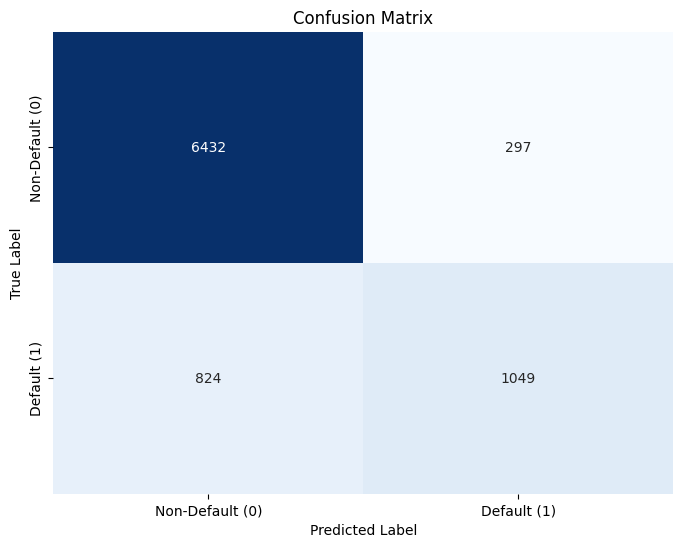

Confusion Matrix:
[[6432  297]
 [ 824 1049]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test_aligned, pred)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Default (0)', 'Default (1)'],
            yticklabels=['Non-Default (0)', 'Default (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Confusion Matrix:")
print(cm)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np # Import numpy for np.number

# Identify categorical columns (same as for statsmodels)
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Apply one-hot encoding to training and testing data
x_train_sklearn = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_sklearn = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Align columns to ensure both datasets have the same columns in the same order
# This is crucial if one-hot encoding creates different columns in train vs test
common_cols = list(set(x_train_sklearn.columns) | set(x_test_sklearn.columns))
x_train_sklearn = x_train_sklearn.reindex(columns=common_cols, fill_value=0)
x_test_sklearn = x_test_sklearn.reindex(columns=common_cols, fill_value=0)

# Handle potential NaN values by filling with the mean for numerical columns
numerical_cols_with_nans_train = x_train_sklearn.select_dtypes(include=np.number).isnull().sum()[x_train_sklearn.select_dtypes(include=np.number).isnull().sum() > 0].index.tolist()
numerical_cols_with_nans_test = x_test_sklearn.select_dtypes(include=np.number).isnull().sum()[x_test_sklearn.select_dtypes(include=np.number).isnull().sum() > 0].index.tolist()

for col in numerical_cols_with_nans_train:
    x_train_sklearn[col] = x_train_sklearn[col].fillna(x_train_sklearn[col].mean())

for col in numerical_cols_with_nans_test:
    x_test_sklearn[col] = x_test_sklearn[col].fillna(x_test_sklearn[col].mean())

# Ensure all columns are numeric (float) after one-hot encoding and imputation
x_train_sklearn = x_train_sklearn.astype(float)
x_test_sklearn = x_test_sklearn.astype(float)

scaler = StandardScaler()
numerical_features = x_train_sklearn.select_dtypes(include=[np.number]).columns.tolist()
original_numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

numerical_cols_to_scale = [col for col in original_numerical_cols if col in x_train_sklearn.columns]

x_train_sklearn[numerical_cols_to_scale] = scaler.fit_transform(x_train_sklearn[numerical_cols_to_scale])
x_test_sklearn[numerical_cols_to_scale] = scaler.transform(x_test_sklearn[numerical_cols_to_scale])


logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train_sklearn, y_train)

print("Logistic Regression model fitted successfully with preprocessed and scaled data.")

Logistic Regression model fitted successfully with preprocessed and scaled data.


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

# The error occurred because x_train contains categorical (string) data.
# You need to use the preprocessed and scaled data (x_train_sklearn) for model training.
logistic_model.fit(x_train_sklearn, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the scaled test set using the sklearn model
sklearn_pred = logistic_model.predict(x_test_sklearn)

# Generate and print the classification report
print("Classification Report for scikit-learn Logistic Regression:")
print(classification_report(y_test, sklearn_pred))

Classification Report for scikit-learn Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7626
           1       0.78      0.55      0.65      2149

    accuracy                           0.87      9775
   macro avg       0.83      0.75      0.78      9775
weighted avg       0.86      0.87      0.86      9775



In [ ]:
pred = logistic_model.predict(x_test_sklearn)
pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
x_test1 = x_test.copy()
x_test1['Default_pred'] = pred
x_test1['Default'] = y_test
x_test1

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Default_pred,Default
29088,27,47900,OWN,1.0,VENTURE,C,7500,13.47,0.16,N,6,0,0
24708,34,73000,RENT,0.0,PERSONAL,B,10000,11.11,0.14,N,10,0,0
22316,32,54000,MORTGAGE,16.0,MEDICAL,A,10000,7.74,0.19,N,7,0,0
15922,23,38000,RENT,3.0,PERSONAL,A,19750,7.51,0.52,N,4,1,1
4987,24,42996,RENT,5.0,MEDICAL,A,5000,7.14,0.12,N,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14102,24,100000,MORTGAGE,5.0,PERSONAL,B,14000,10.75,0.14,N,3,0,0
3586,26,37500,MORTGAGE,4.0,DEBTCONSOLIDATION,A,7000,6.54,0.19,N,4,0,0
4755,22,30000,RENT,0.0,EDUCATION,B,5000,10.33,0.17,N,3,0,0
3137,21,26400,RENT,6.0,DEBTCONSOLIDATION,A,3500,8.49,0.13,N,3,0,1


menambahkan hasil prediksi model ke dalam dataset testing asli untuk perbandingan dengan nilai default yang sebenarnya.

In [ ]:
accuracy_score(y_test, pred) * 100

86.7314578005115

# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors= 7)
knn_model.fit(x_train_sklearn, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = knn_model.predict(x_test_sklearn)
accuracy_score(y_test, y_pred) * 100

88.75703324808184

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors= neighbor_num)
    knn_model.fit(x_train_sklearn, y_train)

    train_pred = knn_model.predict(x_train_sklearn)
    test_pred = knn_model.predict(x_test_sklearn)
    train_acc_score = accuracy_score(y_train, train_pred) * 100
    test_acc_score = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)
    print("Neighbors_num: {0} --> Accuracy on Test Set: {1} %".format(neighbor_num, np.round(test_acc_score, 2)))

Neighbors_num: 1 --> Accuracy on Test Set: 85.37 %
Neighbors_num: 3 --> Accuracy on Test Set: 87.77 %
Neighbors_num: 5 --> Accuracy on Test Set: 88.46 %
Neighbors_num: 7 --> Accuracy on Test Set: 88.76 %
Neighbors_num: 9 --> Accuracy on Test Set: 88.87 %
Neighbors_num: 11 --> Accuracy on Test Set: 88.83 %
Neighbors_num: 13 --> Accuracy on Test Set: 88.91 %
Neighbors_num: 15 --> Accuracy on Test Set: 88.9 %
Neighbors_num: 17 --> Accuracy on Test Set: 88.81 %
Neighbors_num: 19 --> Accuracy on Test Set: 88.76 %
Neighbors_num: 21 --> Accuracy on Test Set: 88.83 %


In [ ]:
performance_df = pd.DataFrame({
    'Neighbors_num' : neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})

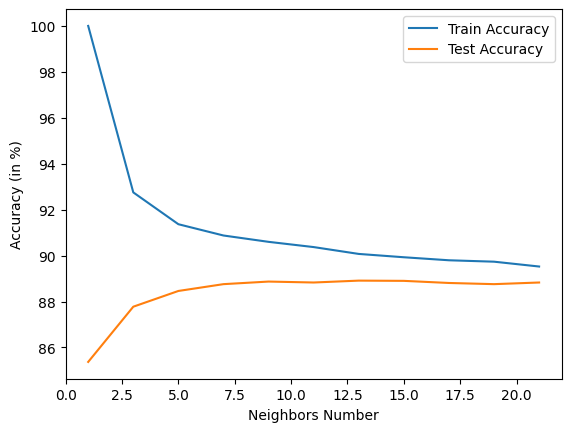

In [ ]:
plt.plot(
    performance_df['Neighbors_num'] ,performance_df['Train Accuracy'],
    performance_df['Neighbors_num'] ,performance_df['Test Accuracy']
)
plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (in %)")
plt.legend(['Train Accuracy', 'Test Accuracy'])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[7396  230]
 [ 869 1280]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      7626
           1       0.85      0.60      0.70      2149

    accuracy                           0.89      9775
   macro avg       0.87      0.78      0.82      9775
weighted avg       0.88      0.89      0.88      9775



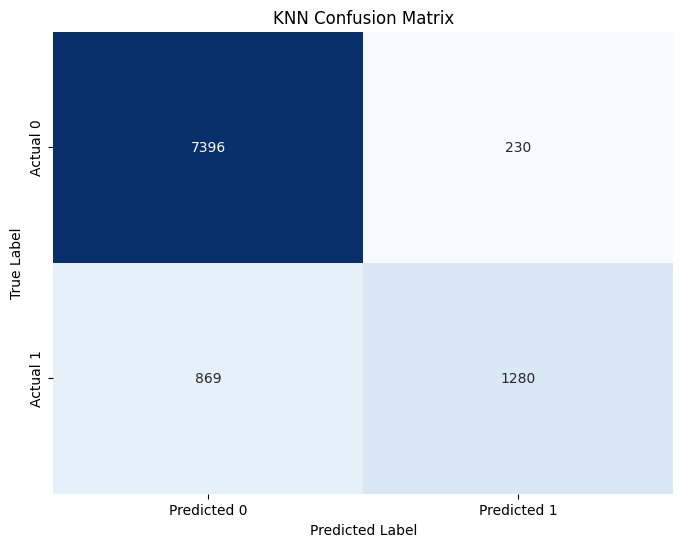

KNN Confusion Matrix:
[[7396  230]
 [ 869 1280]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

knn_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('KNN Confusion Matrix')
plt.show()

print("KNN Confusion Matrix:")
print(knn_cm)

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing

In [ ]:
classifier = DecisionTreeClassifier()
classifier.fit(x_train_sklearn, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = classifier.predict(x_test_sklearn)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[7058  568]
 [ 521 1628]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7626
           1       0.74      0.76      0.75      2149

    accuracy                           0.89      9775
   macro avg       0.84      0.84      0.84      9775
weighted avg       0.89      0.89      0.89      9775



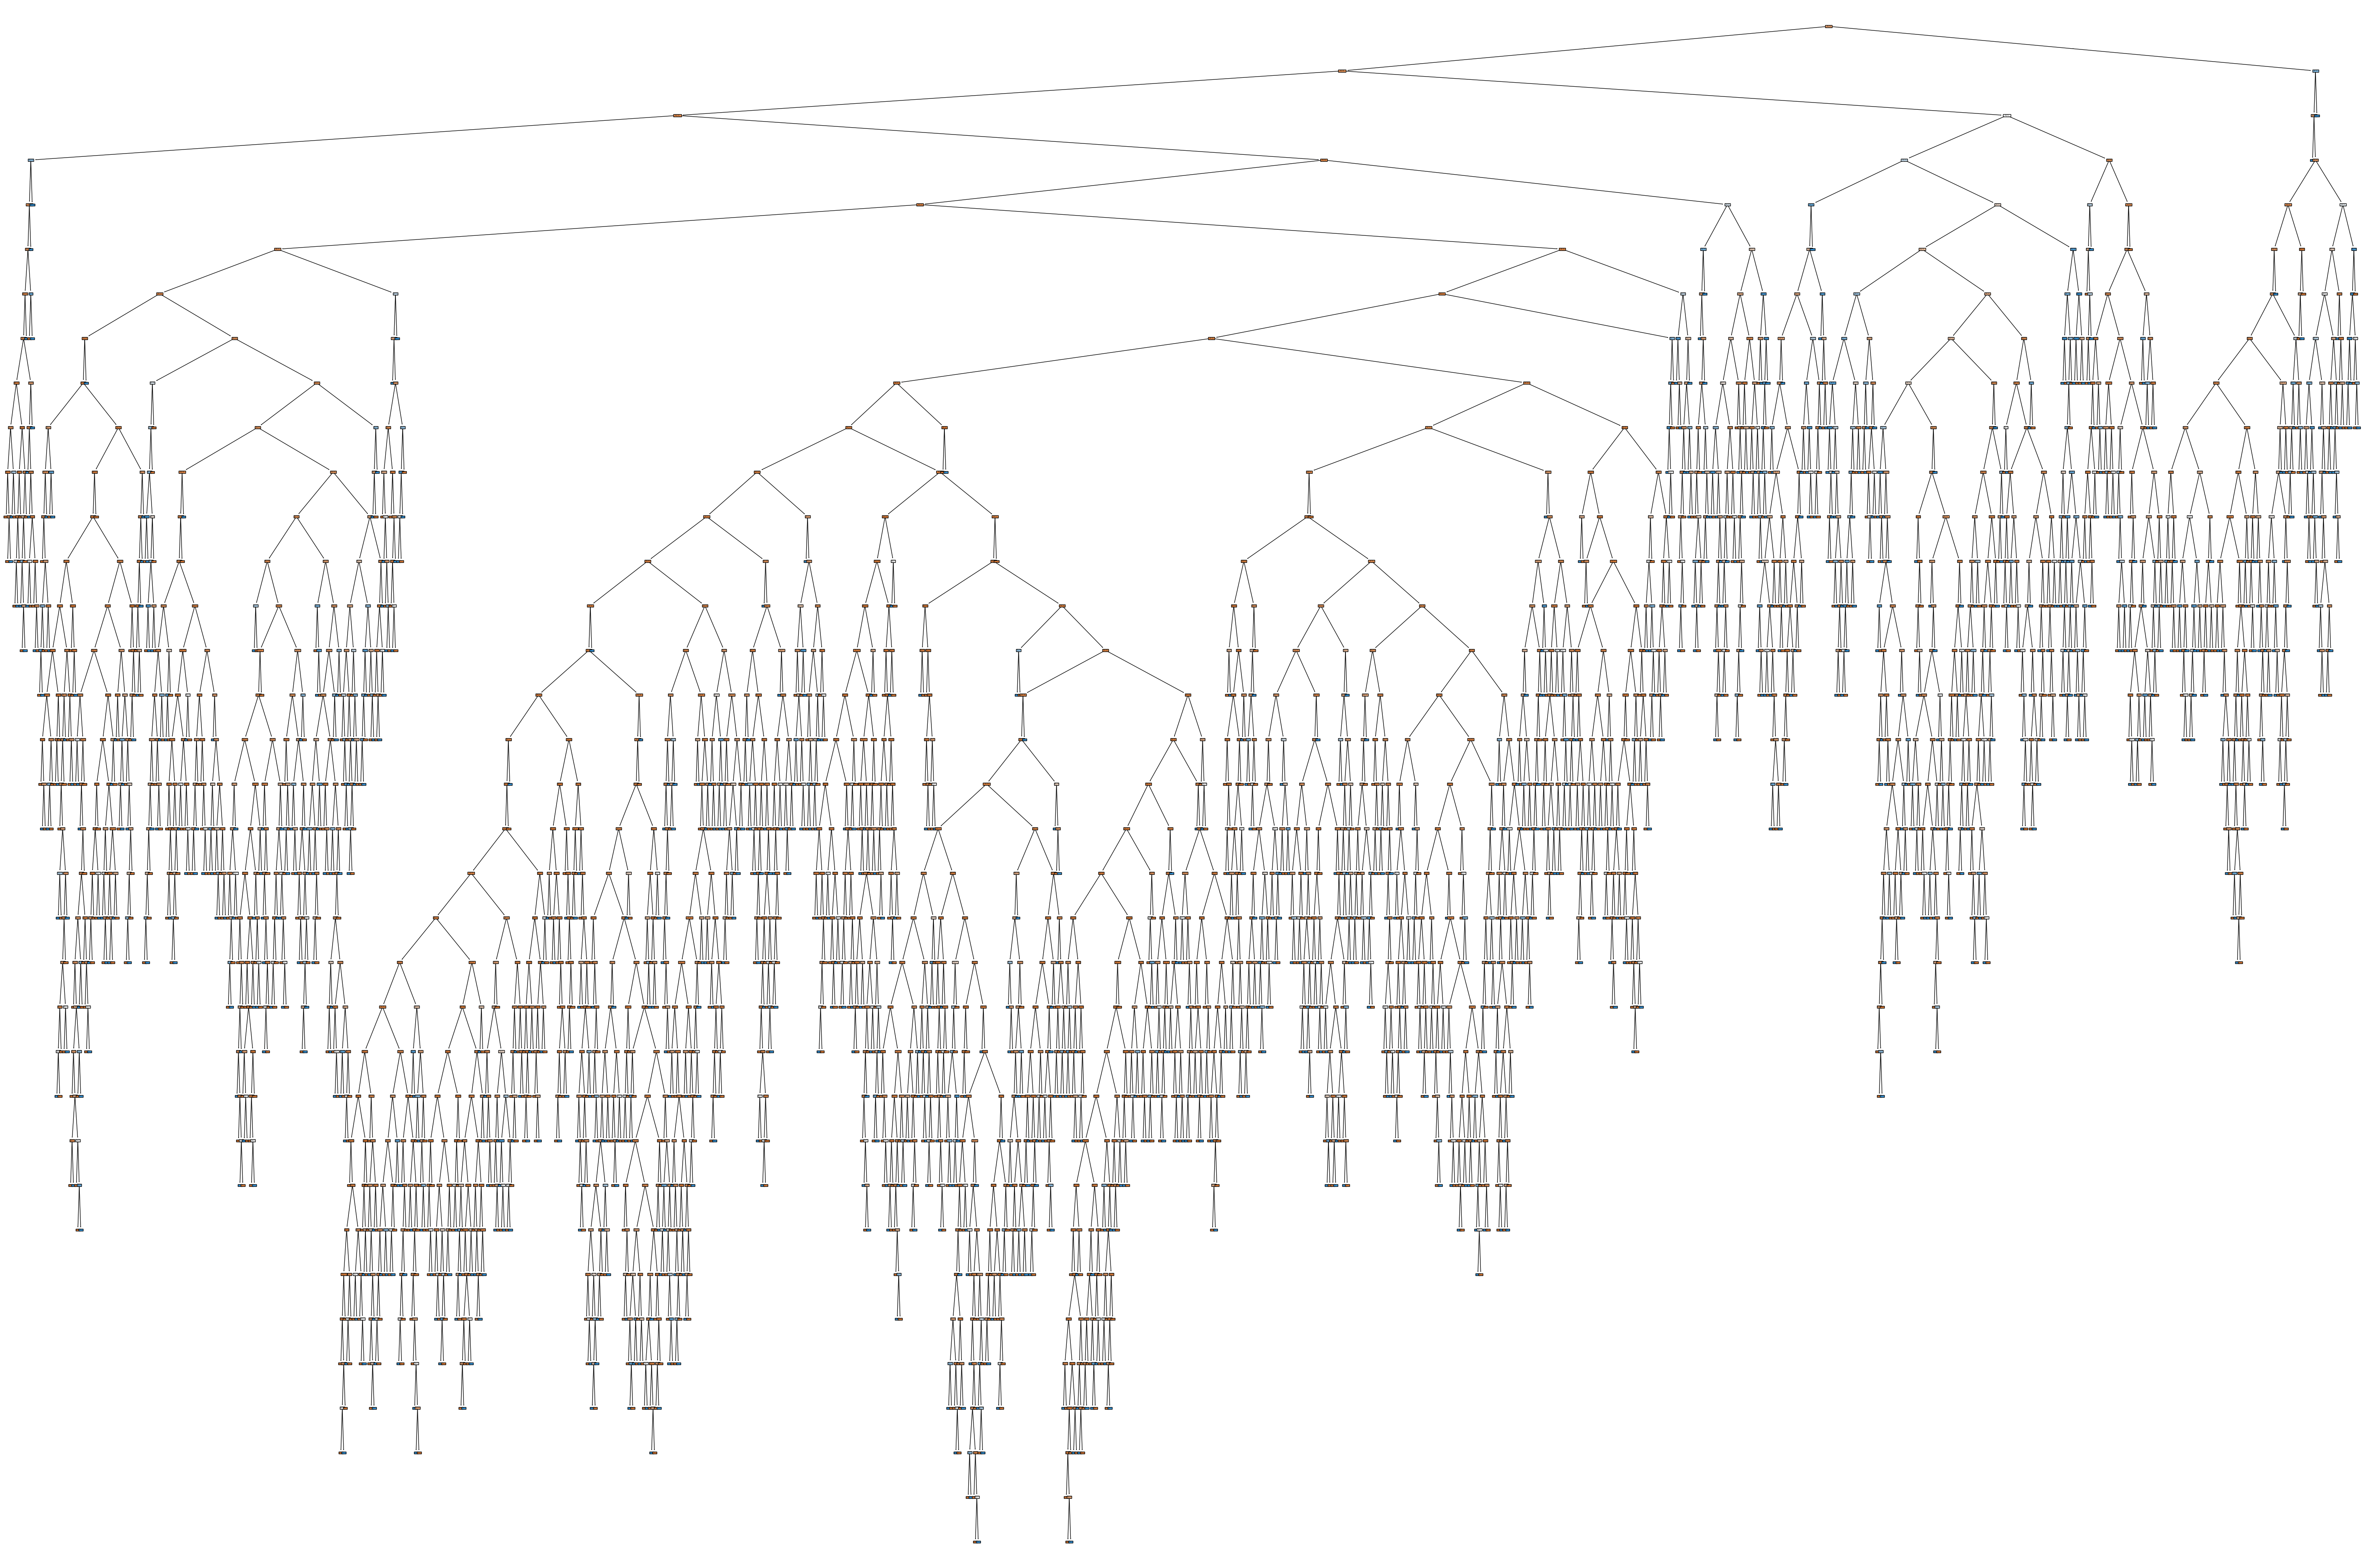

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize = (75,50))
plot_tree(classifier.fit(x_train_sklearn, y_train), filled=True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure x and y are defined before splitting
x = credit_risk_dataset.drop(columns= "loan_status")
y = credit_risk_dataset.loan_status

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# Identify categorical columns
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Apply one-hot encoding to training and testing data
x_train_sklearn = pd.get_dummies(x_train, columns=categorical_cols, drop_first=True)
x_test_sklearn = pd.get_dummies(x_test, columns=categorical_cols, drop_first=True)

# Align columns to ensure both datasets have the same columns in the same order
# This is crucial if one-hot encoding creates different columns in train vs test
common_cols = list(set(x_train_sklearn.columns) | set(x_test_sklearn.columns))
x_train_sklearn = x_train_sklearn.reindex(columns=common_cols, fill_value=0)
x_test_sklearn = x_test_sklearn.reindex(columns=common_cols, fill_value=0)

# Handle potential NaN values by filling with the mean for numerical columns
numerical_cols_with_nans_train = x_train_sklearn.select_dtypes(include=np.number).isnull().sum()[x_train_sklearn.select_dtypes(include=np.number).isnull().sum() > 0].index.tolist()
numerical_cols_with_nans_test = x_test_sklearn.select_dtypes(include=np.number).isnull().sum()[x_test_sklearn.select_dtypes(include=np.number).isnull().sum() > 0].index.tolist()

for col in numerical_cols_with_nans_train:
    x_train_sklearn[col] = x_train_sklearn[col].fillna(x_train_sklearn[col].mean())

for col in numerical_cols_with_nans_test:
    x_test_sklearn[col] = x_test_sklearn[col].fillna(x_test_sklearn[col].mean())

# Ensure all columns are numeric (float) after one-hot encoding and imputation
x_train_sklearn = x_train_sklearn.astype(float)
x_test_sklearn = x_test_sklearn.astype(float)

scaler = StandardScaler()
original_numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

numerical_cols_to_scale = [col for col in original_numerical_cols if col in x_train_sklearn.columns]

x_train_sklearn[numerical_cols_to_scale] = scaler.fit_transform(x_train_sklearn[numerical_cols_to_scale])
x_test_sklearn[numerical_cols_to_scale] = scaler.transform(x_test_sklearn[numerical_cols_to_scale])

# Instantiate the classifier
rfc = RandomForestClassifier(random_state=0)

# Fit the model
rfc.fit(x_train_sklearn, y_train)

print("Random Forest Classifier model fitted successfully with preprocessed and scaled data.")

Random Forest Classifier model fitted successfully with preprocessed and scaled data.


In [ ]:
# import Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

# instantiate the classifier

rfc = RandomForestClassifier(random_state=0)

# fit the model

rfc.fit(x_train_sklearn, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Predict the Test set results

y_pred = rfc.predict(x_test_sklearn)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9304


In [ ]:
# define the parameter list
max_depth_tree_list = np.arange(1, 20, 2)
tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['log_loss', 'gini', 'entropy'],
}

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

grid_search = GridSearchCV(
    estimator= DecisionTreeClassifier(),
    param_grid= tree_params_list,
    cv= StratifiedKFold(n_splits= 3),
    scoring= 'precision'
)
grid_search.fit(x_train_sklearn, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['log_loss', 'gini', 'entropy'],
                         'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='precision')

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(7))

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_best = best_model.predict(x_test_sklearn) # Changed x_test to x_test_sklearn
y_best

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best))

[[7587   39]
 [ 834 1315]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      7626
           1       0.97      0.61      0.75      2149

    accuracy                           0.91      9775
   macro avg       0.94      0.80      0.85      9775
weighted avg       0.92      0.91      0.90      9775



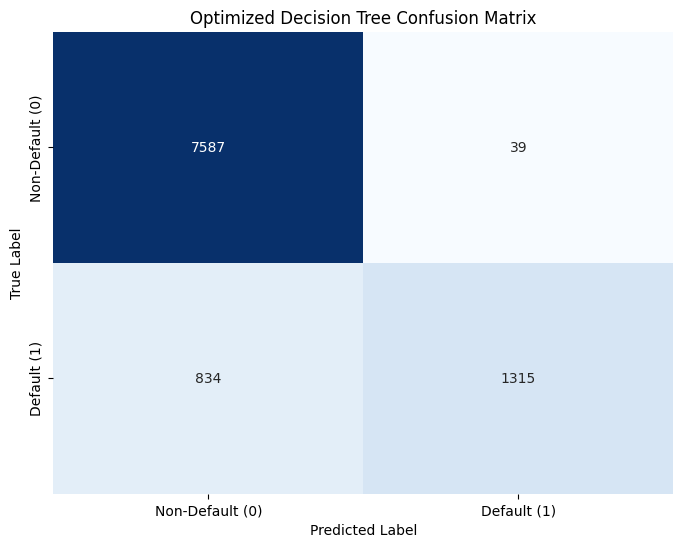

Optimized Decision Tree Confusion Matrix:
[[7587   39]
 [ 834 1315]]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_best_model = confusion_matrix(y_test, y_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_model, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Default (0)', 'Default (1)'],
            yticklabels=['Non-Default (0)', 'Default (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Optimized Decision Tree Confusion Matrix')
plt.show()

print("Optimized Decision Tree Confusion Matrix:")
print(cm_best_model)

# **Support Vector Machine**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn import datasets
from sklearn.metrics import confusion_matrix

In [ ]:
parameter={
    'kernel':('linear','poly','rbf'),
    'C':[0.0001,0.001,0.01,0.1,1,10,100,1000,10000],
    'gamma':[0.0001,0.001,0.01,0.1,1,10,100,1000,10000]
}

grid=GridSearchCV(model,parameter,cv=cv,n_jobs=1,scoring='accuracy')

grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=<statsmodels.discrete.discrete_model.Logit object at 0x7c249350ec30>,
             n_jobs=1,
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                               10000],
                         'gamma': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000,
                                   10000],
                         'kernel': ('linear', 'poly', 'rbf')},
             scoring='accuracy')

In [ ]:
from sklearn import svm
svm_model=svm.SVC(class_weight=None,C=1,gamma=0.1,kernel='linear',random_state=100)
n=5
from sklearn.model_selection import StratifiedKFold
kf=StratifiedKFold(n_splits=n,random_state=None)

In [ ]:
svm_model.fit(x_train_sklearn, y_train)
y_pred = svm_model.predict(x_test_sklearn)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[7294  332]
 [ 966 1183]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      7626
           1       0.78      0.55      0.65      2149

    accuracy                           0.87      9775
   macro avg       0.83      0.75      0.78      9775
weighted avg       0.86      0.87      0.86      9775



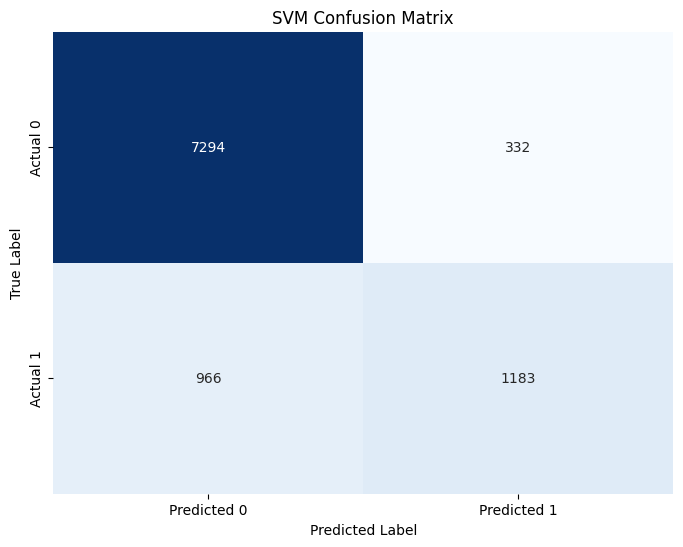

SVM Confusion Matrix:
[[7294  332]
 [ 966 1183]]


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the SVM model
svm_cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()

print("SVM Confusion Matrix:")
print(svm_cm)